In [2]:
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.3.0+cu121.html
!pip install torch_geometric
!pip install deepchem
!pip install rdkit
!pip install torchinfo
!pip install molfeat

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.0/781.0 MB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 112.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 96.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 73.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 45.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 101.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
import os
os.chdir('Thesis')

In [4]:
import random
import numpy as np
import torch

def seed_set(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
%load modules/data_handler.py

In [5]:
from modules.data_handler import scaffold_split_indices, FingerprintsDescriptorsCalculator, PCAReducer, DTsetBasic
from torch_geometric.loader import DataLoader

## For Test Result :
import os
import numpy as np
import torch
import torch.nn as nn
from torch import device
from torch.utils.data import DataLoader
from torch.nn import Linear
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter

from torch_geometric.nn import GINConv
from torch_geometric.nn import global_add_pool
from torch_geometric.loader import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from torch.optim import Adam

from torch_geometric.nn import GCNConv, TopKPooling, global_mean_pool
from torch_geometric.nn import global_mean_pool as gap, global_max_pool as gmp

from copy import deepcopy
from math import sqrt
from tqdm.notebook import tqdm

Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


### Load Data and Calculate FP, DESCs

In [8]:
import pandas as pd

df = pd.read_csv('/content/bace.csv')
smiles_column = df['mol'].values

In [9]:
target = df['Class']
target

,Class
0,1
1,1
2,1
3,1
4,1
...,...
1508,0
1509,0
1510,0
1511,0


In [10]:
len(smiles_column)

1513

In [11]:
calculator = FingerprintsDescriptorsCalculator(smiles_column)

ecfp = calculator.calculate_ecfp()
topological = calculator.calculate_topological()
maccs = calculator.calculate_maccs()
estate = calculator.calculate_estate()
rdkit2D = calculator.calculate_rdkit2D()
phar2D = calculator.calculate_phar2D()

invalid_indices = calculator.get_invalid_indices()
valid_smiles = calculator.get_valid_smiles()

0it [00:00, ?it/s]

In [12]:
print(ecfp.shape)
print(topological.shape)
print(maccs.shape)
print(estate.shape)
print(rdkit2D.shape)
print(phar2D.shape)

(1513, 2048)
(1513, 2048)
(1513, 167)
(1513, 79)
(1513, 216)
(1513, 2048)


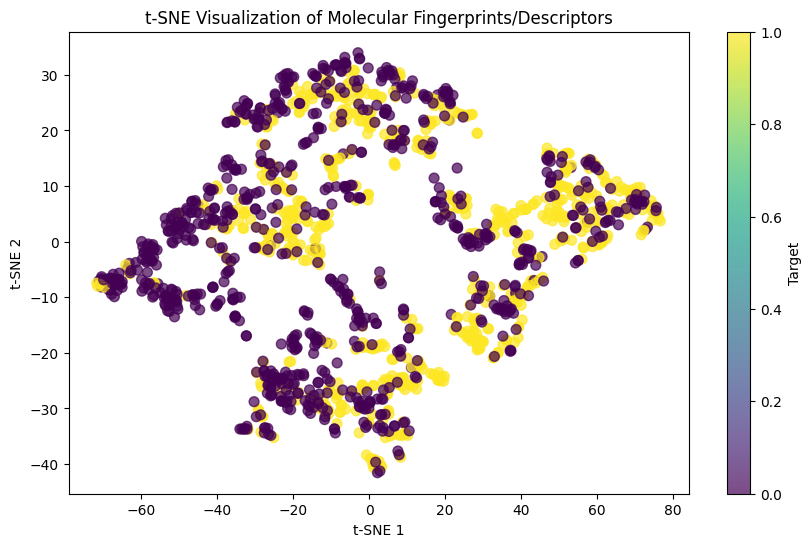

In [61]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

# Assuming fingerprints are numpy arrays or pandas DataFrames
# Concatenate all fingerprints/descriptors into one matrix
combined_features = np.concatenate([ecfp, topological, maccs, estate, rdkit2D, phar2D], axis=1)

# Apply t-SNE for dimensionality reduction to 2D
tsne1 = TSNE(n_components=2, random_state=42)
tsne1_results = tsne1.fit_transform(combined_features)

# Plot the t-SNE results, colored by the target values
plt.figure(figsize=(10, 6))
plt.scatter(tsne1_results[:, 0], tsne1_results[:, 1], c=target, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(label='Target')
plt.title('t-SNE Visualization of Molecular Fingerprints/Descriptors')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

<ipython-input-62-82443f45a4c0>:37: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


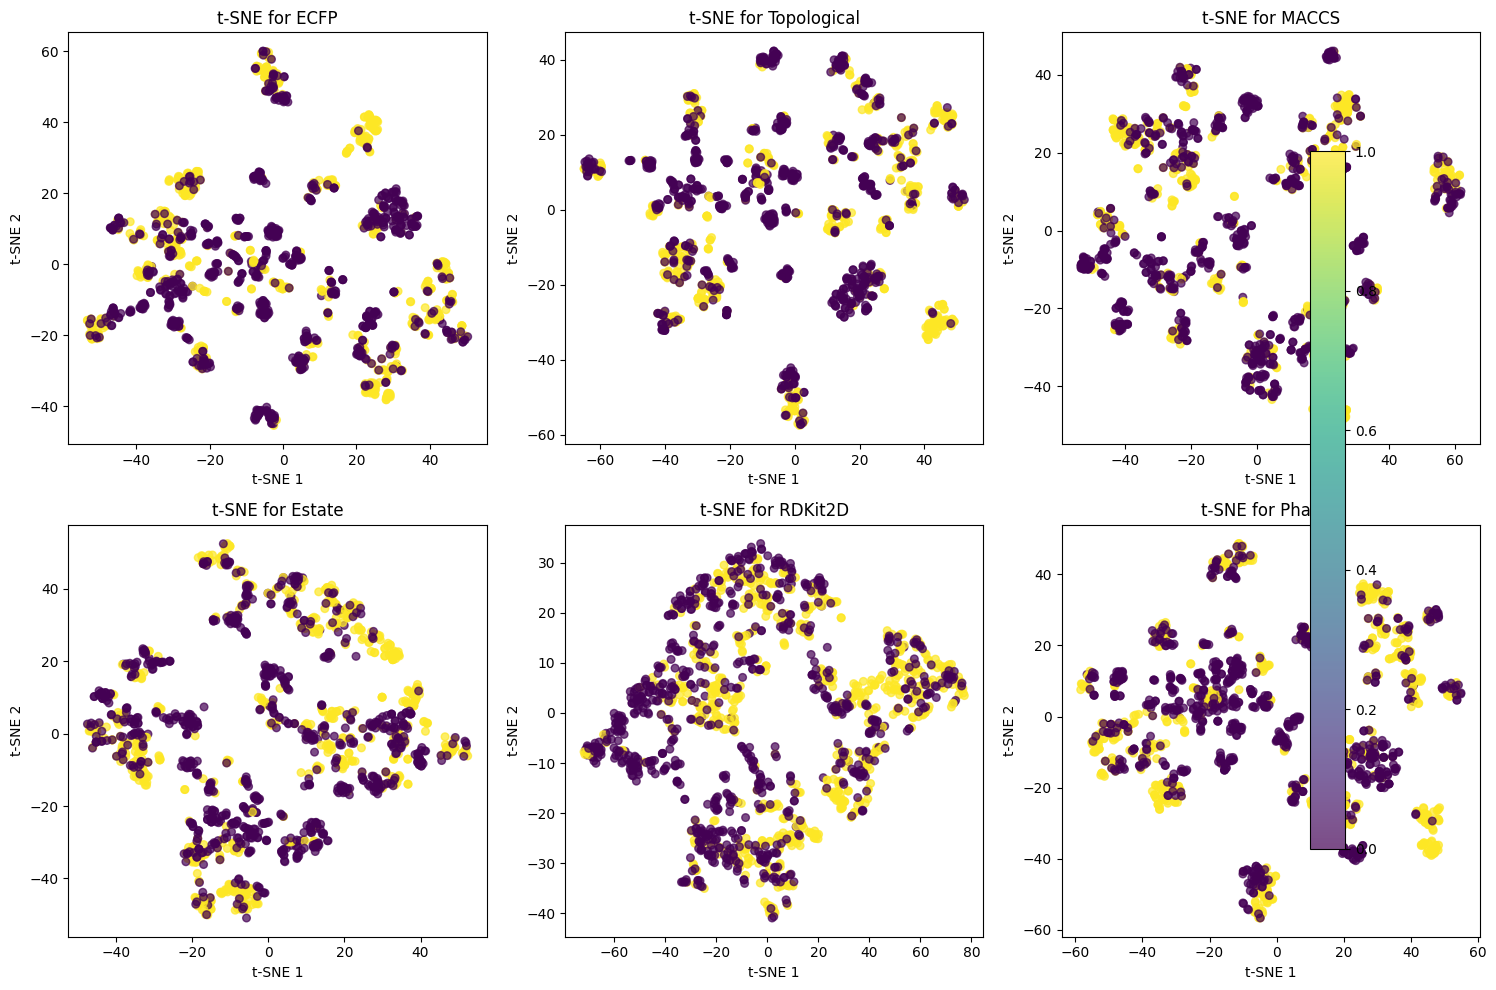

In [62]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# List of fingerprints/descriptors
fingerprints = {
    'ECFP': ecfp,
    'Topological': topological,
    'MACCS': maccs,
    'Estate': estate,
    'RDKit2D': rdkit2D,
    'Phar2D': phar2D
}

# Number of subplots (2 rows, 3 columns for 6 fingerprints/descriptors)
n_cols = 3
n_rows = 2

# Create a figure for subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 10))
axes = axes.flatten()

# Loop through each fingerprint/descriptor and apply t-SNE
for idx, (name, features) in enumerate(fingerprints.items()):
    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(features)

    # Plot each result as a subplot
    scatter = axes[idx].scatter(tsne_result[:, 0], tsne_result[:, 1], c=target, cmap='viridis', s=30, alpha=0.7)
    axes[idx].set_title(f't-SNE for {name}')
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')

# Add a color bar to the last subplot
fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.03, pad=0.04)

# Adjust layout
plt.tight_layout()
plt.show()


In [63]:
invalid_indices

[]

In [64]:
len(valid_smiles)

1513

In [15]:
# Usage Example :
N_COMPONENTS = 64
reducer = PCAReducer(n_components=N_COMPONENTS)

ecfp_reduced = reducer.reduce_ecfp(ecfp)
topological_reduced = reducer.reduce_topological(topological)
maccs_reduced = reducer.reduce_maccs(maccs)
estate_reduced = reducer.reduce_estate(estate)
rdkit2D_reduced = reducer.reduce_rdkit2D(rdkit2D)
phar2D_reduced = reducer.reduce_phar2D(phar2D)

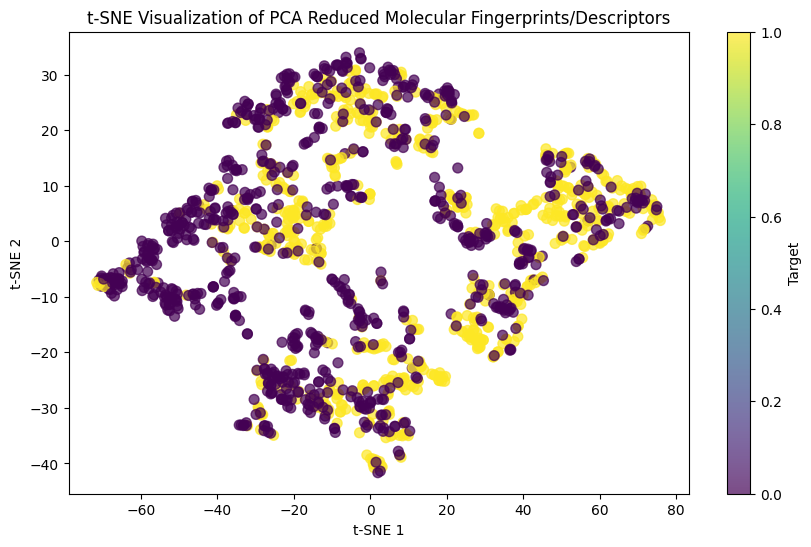

In [65]:
# Assuming fingerprints are numpy arrays or pandas DataFrames
# Concatenate all fingerprints/descriptors into one matrix
combined_features = np.concatenate([ecfp_reduced, topological_reduced, maccs_reduced, estate_reduced, rdkit2D_reduced, phar2D_reduced], axis=1)

# Apply t-SNE for dimensionality reduction to 2D
tsne2 = TSNE(n_components=2, random_state=42)
tsne2_results = tsne2.fit_transform(combined_features)

# Plot the t-SNE results, colored by the target values
plt.figure(figsize=(10, 6))
plt.scatter(tsne2_results[:, 0], tsne2_results[:, 1], c=target, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(label='Target')
plt.title('t-SNE Visualization of PCA Reduced Molecular Fingerprints/Descriptors')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.show()

<ipython-input-66-bd51b5ee35f6>:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for color bar on the right


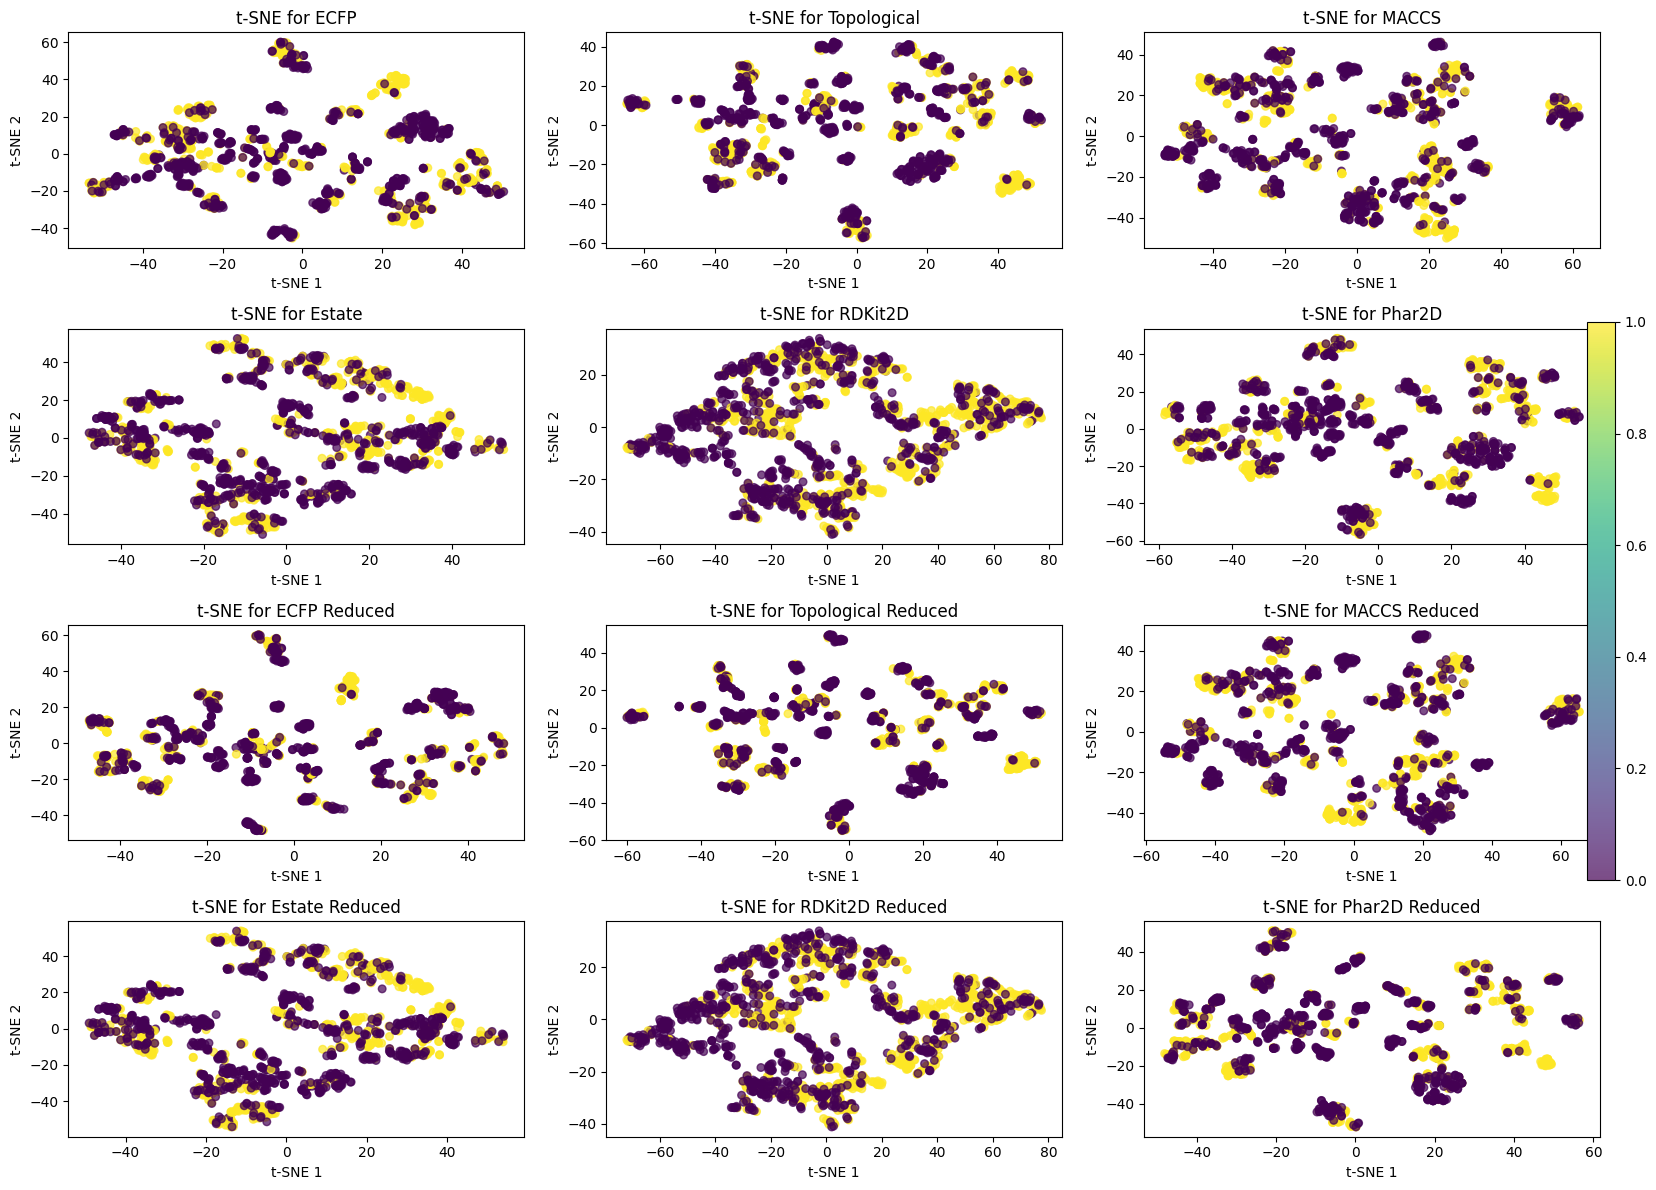

In [66]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Original fingerprints/descriptors
fingerprints = {
    'ECFP': ecfp,
    'Topological': topological,
    'MACCS': maccs,
    'Estate': estate,
    'RDKit2D': rdkit2D,
    'Phar2D': phar2D
}

# Reduced fingerprints/descriptors
reduced_fingerprints = {
    'ECFP Reduced': ecfp_reduced,
    'Topological Reduced': topological_reduced,
    'MACCS Reduced': maccs_reduced,
    'Estate Reduced': estate_reduced,
    'RDKit2D Reduced': rdkit2D_reduced,
    'Phar2D Reduced': phar2D_reduced
}

# Combine original and reduced into one dictionary
all_fingerprints = {**fingerprints, **reduced_fingerprints}

# Number of subplots (4 rows, 3 columns for 12 fingerprints/descriptors)
n_cols = 3
n_rows = 4

# Create a figure for subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))
axes = axes.flatten()

# Loop through each fingerprint/descriptor and apply t-SNE
for idx, (name, features) in enumerate(all_fingerprints.items()):
    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(features)

    # Plot each result as a subplot
    scatter = axes[idx].scatter(tsne_result[:, 0], tsne_result[:, 1], c=target, cmap='viridis', s=30, alpha=0.7)
    axes[idx].set_title(f't-SNE for {name}')
    axes[idx].set_xlabel('t-SNE 1')
    axes[idx].set_ylabel('t-SNE 2')

# Add a single color bar outside the plot
cbar = fig.colorbar(scatter, ax=axes, orientation='vertical', fraction=0.02, pad=0.08)

# Adjust layout to ensure no overlap
plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space for color bar on the right
plt.show()


In [16]:
directory = 'data/basic-64/raw'
CSV_PATH = 'data/basic-64/raw/bace_cleaned.csv'

if not os.path.exists(directory):
    os.makedirs(directory)

df.drop(invalid_indices).to_csv(CSV_PATH)

In [17]:
dataset_64 = DTsetBasic(root='data/basic-64', filename='bace_cleaned.csv', smiles_column='mol', label_column='Class',
    ECFP=ecfp_reduced, Topological=topological_reduced, MACCS=maccs_reduced,
    EState=estate_reduced, Rdkit2D=rdkit2D_reduced, Phar2D=phar2D_reduced)

Processing...


0it [00:00, ?it/s]

Done!


### Scaffold Splitting and Training Testing

In [67]:
########################## Model :

##### GAT-LSTM-GIN
import torch
from torch import nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv, GINConv, BatchNorm, GlobalAttention, GINEConv
from torch_geometric.data import Data, Batch

############### LSTM Pooling ###############
class LSTMAttentionPooling(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1):
        super(LSTMAttentionPooling, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, x, batch):
        # x: [num_nodes, input_dim]
        # batch: [num_nodes] indicates which graph each node belongs to

        # Group nodes by graph
        num_graphs = batch.max().item() + 1
        node_embeddings_list = [x[batch == i] for i in range(num_graphs)]

        pooled_outputs = []
        for node_embeds in node_embeddings_list:
            node_embeds = node_embeds.unsqueeze(0)  # [1, num_nodes, input_dim]
            h_0 = torch.zeros(1, 1, node_embeds.size(2)).to(x.device)
            c_0 = torch.zeros(1, 1, node_embeds.size(2)).to(x.device)
            lstm_out, _ = self.lstm(node_embeds, (h_0, c_0))  # [1, num_nodes, hidden_dim]

            attention_weights = F.softmax(self.attention(lstm_out.squeeze(0)), dim=0)  # [num_nodes, 1]
            graph_embedding = torch.sum(attention_weights * lstm_out.squeeze(0), dim=0)  # [hidden_dim]
            pooled_outputs.append(graph_embedding)

        graph_embeddings = torch.stack(pooled_outputs, dim=0)
        return graph_embeddings

############### GRU Pooling ###############
class GRUAttentionPooling(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(GRUAttentionPooling, self).__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, batch_first=True)
        self.attention = nn.Linear(hidden_dim, 1)

    def forward(self, x, batch):
        batch_size = batch.max().item() + 1
        max_num_nodes = (batch == 0).sum().item()
        x_packed = torch.zeros((batch_size, max_num_nodes, x.size(1)), device=x.device)

        for i in range(batch_size):
            nodes_in_batch = x[batch == i].unsqueeze(0)
            h, _ = self.gru(nodes_in_batch)
            attention_weights = F.softmax(self.attention(h), dim=1)
            x_packed[i] = torch.sum(attention_weights * h, dim=1)

        return x_packed[:, 0, :]



############### GIN-GAT ###############
class GINGAT(torch.nn.Module):
    def __init__(self, node_dim, edge_dim, hidden_channels, out_channels, heads, dropout, pooling_type, num_tasks):
        super(GINGAT, self).__init__()

        # Define graph-level GNN layers with GINEConv (with edge attributes)
        self.graph_conv1 = GINEConv(nn.Sequential(nn.Linear(node_dim, hidden_channels), nn.ReLU(), nn.Linear(hidden_channels, hidden_channels)), edge_dim=edge_dim)
        self.graph_bn1 = BatchNorm(hidden_channels)

        self.graph_conv2 = GINEConv(nn.Sequential(nn.Linear(hidden_channels, hidden_channels), nn.ReLU(), nn.Linear(hidden_channels, hidden_channels)), edge_dim=edge_dim)
        self.graph_bn2 = BatchNorm(hidden_channels)

        self.graph_conv3 = GINEConv(nn.Sequential(nn.Linear(hidden_channels, hidden_channels), nn.ReLU(), nn.Linear(hidden_channels, hidden_channels)), edge_dim=edge_dim)
        self.graph_bn3 = BatchNorm(hidden_channels)

        self.graph_conv4 = GINEConv(nn.Sequential(nn.Linear(hidden_channels, out_channels), nn.ReLU(), nn.Linear(out_channels, out_channels)), edge_dim=edge_dim)
        self.graph_bn4 = BatchNorm(out_channels)

        # Pooling
        self.pooling_type = pooling_type
        if pooling_type == 'lstm':
            self.pooling = LSTMAttentionPooling(out_channels, out_channels)
        elif pooling_type == 'gru':
            self.pooling = GRUAttentionPooling(out_channels, out_channels)
        elif pooling_type == 'attention':
            self.pooling = GlobalAttention(gate_nn=nn.Linear(out_channels, 1))
        else:
            raise ValueError("please use lstm, gru or attention for pooling")

        # Define node-level GNN with GATv2Conv (without edge attributes) and fully connected layers
        self.node_conv1 = GATv2Conv(out_channels, hidden_channels, heads=heads, concat=False)
        self.node_bn1 = BatchNorm(hidden_channels)

        self.fc1 = nn.Linear(hidden_channels, hidden_channels // 2)
        self.fc2 = nn.Linear(hidden_channels // 2, num_tasks)
        self.dropout = nn.Dropout(dropout)
        self.reset_parameters()

    def forward(self, x, edge_index, edge_attr, batch, data):
        device = x.device
        edge_attr = edge_attr.float().to(device)

        # Graph-level GNN
        x = self.graph_conv1(x, edge_index, edge_attr)
        x = self.graph_bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.graph_conv2(x, edge_index, edge_attr)
        x = self.graph_bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.graph_conv3(x, edge_index, edge_attr)
        x = self.graph_bn3(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.graph_conv4(x, edge_index, edge_attr)
        x = self.graph_bn4(x)
        x = F.relu(x)

        # GRU-based pooling with attention
        graph_out = self.pooling(x, batch)

        # Extract fingerprints and descriptors from data
        fingerprints = [data.ECFP.to(device), data.Topological.to(device), data.MACCS.to(device), data.EState.to(device)]
        descriptors = [data.Rdkit2D.to(device), data.Phar2D.to(device)]

        features = fingerprints + descriptors

        # Ensure all features are 2D tensors and concatenate with graph_out
        features = [f.unsqueeze(0) if f.dim() == 1 else f for f in features]

        # Create dummy graphs for the entire batch
        dummy_graphs = []
        for i in range(graph_out.size(0)):
            dummy_graph = self.create_dummy_graph(graph_out[i].unsqueeze(0), [f[i].unsqueeze(0) for f in features], device)
            dummy_graphs.append(dummy_graph)

        # Batch all dummy graphs into a single Batch object
        batched_dummy_graph = Batch.from_data_list(dummy_graphs).to(device)

        # Node-level GNN on the batched dummy graph
        x, edge_index = batched_dummy_graph.x, batched_dummy_graph.edge_index

        x = self.node_conv1(x, edge_index)
        x = self.node_bn1(x)
        x = F.relu(x)

        # Collect predictions from the central nodes
        central_node_indices = torch.arange(0, len(dummy_graphs) * (len(features) + 1), len(features) + 1, device=device)
        final_x = x[central_node_indices]

        # Fully connected layers
        x = F.relu(self.fc1(final_x))
        x = self.dropout(x)
        predictions = self.fc2(x)

        return predictions, graph_out, final_x


    def create_dummy_graph(self, graph_embedding, features, device):
        features = [f.unsqueeze(0).to(device) if f.dim() == 1 else f.to(device) for f in features]
        central_node_features = graph_embedding.to(device)
        node_features = torch.cat([central_node_features] + features, dim=0)
        edges = [[0, i] for i in range(1, len(features) + 1)]
        edge_index = torch.tensor(edges, dtype=torch.long, device=device).t().contiguous()
        dummy_graph = Data(x=node_features, edge_index=edge_index)
        return dummy_graph

    def reset_parameters(self):
        self.graph_conv1.reset_parameters()
        self.graph_bn1.reset_parameters()

        self.graph_conv2.reset_parameters()
        self.graph_bn2.reset_parameters()

        self.graph_conv3.reset_parameters()
        self.graph_bn3.reset_parameters()

        self.graph_conv4.reset_parameters()
        self.graph_bn4.reset_parameters()

        if self.pooling_type == 'lstm':
            self.pooling.lstm.reset_parameters()
            self.pooling.attention.reset_parameters()

        elif self.pooling_type == 'gru':
            self.pooling.gru.reset_parameters()
            self.pooling.attention.reset_parameters()

        elif self.pooling_type == 'attention':
            self.pooling.reset_parameters()

        self.node_conv1.reset_parameters()
        self.node_bn1.reset_parameters()

        self.fc1.reset_parameters()
        self.fc2.reset_parameters()

In [68]:
def run_epoch_cls(model, optimizer, data_loader, loss_function, device, edge_attr, pass_data):
    """
    Runs a single training/evaluation epoch for a PyG model on a graph property prediction task.

    Args:
        model (torch.nn.Module): The PyG model to be trained/evaluated.
        optimizer (torch.optim.Optimizer or None): The optimizer for training. If None, model is in eval mode.
        data_loader (torch_geometric.data.DataLoader): The data loader for the data (train/val/test).
        loss_function (torch.nn.Module): The loss function to use for training/evaluation.
        device (str): The device to use ("cpu" or "cuda").
        edge_attr (bool): Whether edge attributes are used in the model.
        pass_data (bool): Whether to pass the entire data object to the model.

    Returns:
        tuple: (avg_loss, auc_roc, graph_outs, central_node_features, y_true)
    """
    model.to(device)
    model.train() if optimizer is not None else model.eval()

    y_true = []
    y_pred = []
    graph_outs = []
    central_node_features = []
    losses = []

    for data in tqdm(data_loader, desc="Iteration"):
        data = data.to(device)

        # Forward pass
        if edge_attr:
            if pass_data:
                pred, graph_out, x_central = model(data.x, data.edge_index, data.edge_attr, data.batch, data)
            else:
                pred, graph_out, x_central = model(data.x, data.edge_index, data.edge_attr, data.batch)
        else:
            if pass_data:
                pred, graph_out, x_central = model(data.x, data.edge_index, data.batch, data)
            else:
                pred, graph_out, x_central = model(data.x, data.edge_index, data.batch)

        # Loss calculation
        loss = loss_function(pred, data.y.to(torch.float32))

        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Collect losses, predictions, and features
        losses.append(loss.detach().cpu().numpy())
        y_true.append(data.y.view(pred.shape).detach().cpu())
        y_pred.append(pred.detach().cpu())
        graph_outs.append(graph_out.detach().cpu())
        central_node_features.append(x_central.detach().cpu())  # Collect central node features

    # Concatenate results across batches
    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()

    graph_outs = torch.cat(graph_outs, dim=0)
    central_node_features = torch.cat(central_node_features, dim=0)  # Concatenate central node features

    # Calculate ROC-AUC score
    auc_roc = roc_auc_score(y_true, y_pred)

    return np.array(losses).mean(), auc_roc, graph_outs, central_node_features, y_true

In [69]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


def plot_tsne(features, labels, title):
    """
    Visualizes t-SNE of the features.

    Args:
        features (torch.Tensor): The features to visualize.
        labels (torch.Tensor): The ground truth labels corresponding to the features.
        title (str): The title for the plot.
    """
    tsne = TSNE(n_components=2, random_state=0)
    tsne_result = tsne.fit_transform(features)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=labels, cmap='viridis', marker='o')
    plt.colorbar(scatter)
    plt.title(title)
    plt.show()


def train_cls(model, optimizer, loss_function, train_loader, val_loader, num_epochs, device, edge_attr, pass_data, tensorboard_writer):
    writer = SummaryWriter(f'runs/{tensorboard_writer}')

    best_model = None
    best_val_auc = 0
    best_val_loss = float('inf')

    for epoch in range(1, num_epochs + 1):
        # Training phase
        train_loss, train_auc, _, _, _ = run_epoch_cls(model, optimizer, train_loader, loss_function, device, edge_attr, pass_data)
        writer.add_scalar('loss/train', train_loss, epoch)
        writer.add_scalar('auc/train', train_auc, epoch)

        # Validation phase (and collecting features for t-SNE)
        val_loss, val_auc, val_graph_out, val_central_features, val_y = run_epoch_cls(model, None, val_loader, loss_function, device, edge_attr, pass_data)
        writer.add_scalar('loss/val', val_loss, epoch)
        writer.add_scalar('auc/val', val_auc, epoch)

        # if epoch % 10 == 0:
        #     # Log t-SNE visualization for graph-level features and central node features
        #     plot_tsne(val_graph_out.numpy(), val_y, title=f"Epoch {epoch} - t-SNE of Graph-Level Features")
        #     plot_tsne(val_central_features.numpy(), val_y, title=f"Epoch {epoch} - t-SNE of Central Node Features")

        print(f'Epoch: {epoch:03d}, Train loss: {train_loss:.4f}, Train ROC-AUC: {train_auc:.4f}, Val loss: {val_loss:.4f}, Val ROC-AUC: {val_auc:.4f}')

        # Save the best model based on validation AUC
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_val_loss = val_loss
            best_model = deepcopy(model)

    writer.close()

    return {
        'best_model': best_model,
        'best_val_loss': best_val_loss,
        'best_val_auc': best_val_auc
    }


In [70]:
from torchinfo import summary

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [83]:
### Models :
LOSS_FUNCTION = torch.nn.BCEWithLogitsLoss()

model_GinGruGat = GINGAT(node_dim=9, edge_dim=3, hidden_channels=64, out_channels=N_COMPONENTS, heads=6, dropout=0.3, pooling_type='gru', num_tasks=1)
optimizer_GinGruGat = torch.optim.Adam(model_GinGruGat.parameters(), lr=0.002)

In [84]:
## we can view model arcitecture :
# summary(model_GinAttGat)
# summary(model_GinGruGat)
# summary(model_GinLstmGat)

In [85]:
SEED = 42
seed_set(SEED)

split_idx = scaffold_split_indices(valid_smiles, seed=SEED)
train_loader = DataLoader(dataset_64[split_idx["train"]], batch_size=64, shuffle=True)
valid_loader = DataLoader(dataset_64[split_idx["valid"]], batch_size=64, shuffle=False)
test_loader  = DataLoader(dataset_64[split_idx["test"]], batch_size=64, shuffle=False)

##### GRU-Based #####
print("\n start model_GinGruGat: \n ")

results_GinGruGat = train_cls(model = model_GinGruGat,
    optimizer = optimizer_GinGruGat,
    loss_function = LOSS_FUNCTION,
    train_loader = train_loader,
    val_loader = valid_loader,
    num_epochs = 50,
    device = device,
    edge_attr = True,
    pass_data = True,
    tensorboard_writer = "GIN-GRU-GAT")

best_model_gru = results_GinGruGat['best_model']

test_loss_gru, test_auc_gru, _, _, _ = run_epoch_cls(model = best_model_gru, optimizer=None, data_loader=test_loader,
loss_function=LOSS_FUNCTION, device=device, edge_attr=True, pass_data=True)

print(f"\n model_GinGruGat  Test Result :  AUC: {test_auc_gru:.4f}, LOSS: {test_loss_gru:.4f} on seed {SEED} \n")


 start model_GinGruGat: 
 


Iteration:   0%|          | 0/19 [00:00<?, ?it/s]

Iteration:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 001, Train loss: 0.6873, Train ROC-AUC: 0.5284, Val loss: 0.6956, Val ROC-AUC: 0.6416


Iteration:   0%|          | 0/19 [00:00<?, ?it/s]

...

Iteration:   0%|          | 0/19 [00:00<?, ?it/s]

Iteration:   0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 050, Train loss: 0.3069, Train ROC-AUC: 0.9408, Val loss: 0.6376, Val ROC-AUC: 0.7501


Iteration:   0%|          | 0/3 [00:00<?, ?it/s]


 model_GinGruGat  Test Result :  AUC: 0.8290, LOSS: 0.5039 on seed 42 



In [86]:
test_loss_gru, test_auc_gru, _, _, _ = run_epoch_cls(model = best_model_gru, optimizer=None, data_loader=test_loader,
loss_function=LOSS_FUNCTION, device=device, edge_attr=True, pass_data=True)


train_loss, train_auc, train_graph_out, train_final_x, train_y = run_epoch_cls(
    model=best_model_gru, optimizer=None, data_loader=train_loader, loss_function=LOSS_FUNCTION, device=device, edge_attr=True, pass_data=True)

val_loss, val_auc, val_graph_out, val_final_x, val_y = run_epoch_cls(
    model=best_model_gru, optimizer=None, data_loader=valid_loader, loss_function=LOSS_FUNCTION, device=device, edge_attr=True, pass_data=True)

test_loss, test_auc, test_graph_out, test_final_x, test_y = run_epoch_cls(
    model=best_model_gru, optimizer=None, data_loader=test_loader, loss_function=LOSS_FUNCTION, device=device, edge_attr=True, pass_data=True)


# Concatenate results
all_graph_outs = torch.cat([train_graph_out, val_graph_out, test_graph_out], dim=0)

all_final_x = torch.cat([train_final_x, val_final_x, test_final_x], dim=0)

# Since y_true is now returned as a numpy array, convert it to a tensor for concatenation
all_labels = torch.cat([
    torch.tensor(train_y, dtype=torch.float32),
    torch.tensor(val_y, dtype=torch.float32),
    torch.tensor(test_y, dtype=torch.float32)
], dim=0)

# You can now apply t-SNE or other visualizations on all_graph_outs or all_final_x


Iteration:   0%|          | 0/3 [00:00<?, ?it/s]

Iteration:   0%|          | 0/19 [00:00<?, ?it/s]

Iteration:   0%|          | 0/3 [00:00<?, ?it/s]

Iteration:   0%|          | 0/3 [00:00<?, ?it/s]

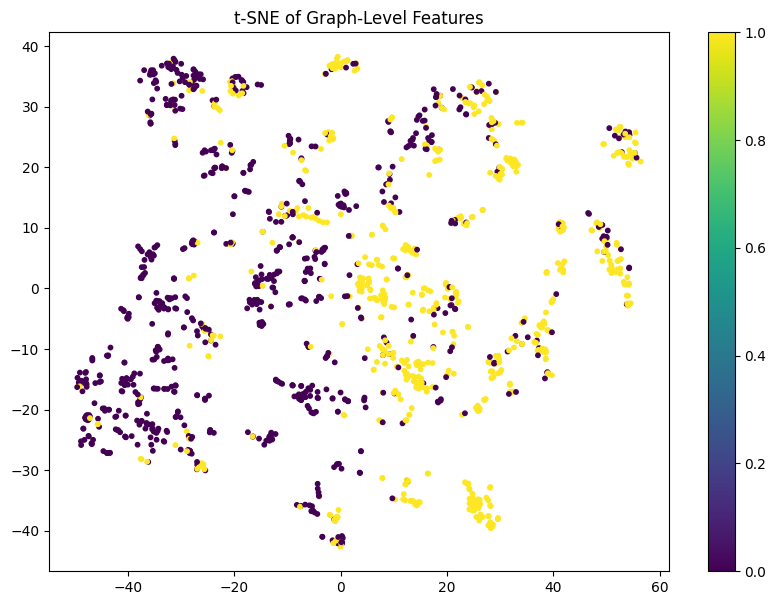

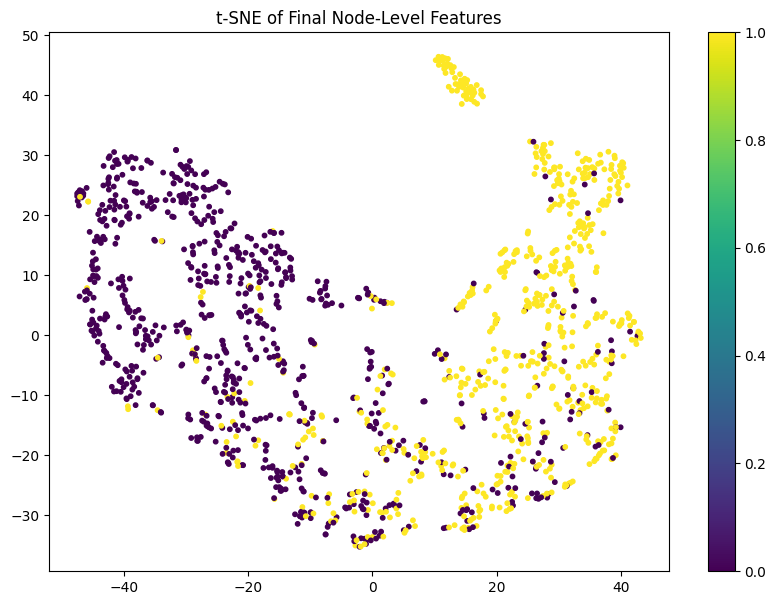

In [87]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne(features, labels, title):
    tsne = TSNE(n_components=2)
    transformed_features = tsne.fit_transform(features)

    plt.figure(figsize=(10, 7))
    scatter = plt.scatter(transformed_features[:, 0], transformed_features[:, 1], c=labels, cmap='viridis', s=10)
    plt.colorbar(scatter)
    plt.title(title)
    plt.show()

# Apply t-SNE on graph-level features
plot_tsne(all_graph_outs.numpy(), all_labels.numpy(), title="t-SNE of Graph-Level Features")

# Apply t-SNE on final central node features
plot_tsne(all_final_x.numpy(), all_labels.numpy(), title="t-SNE of Final Node-Level Features")


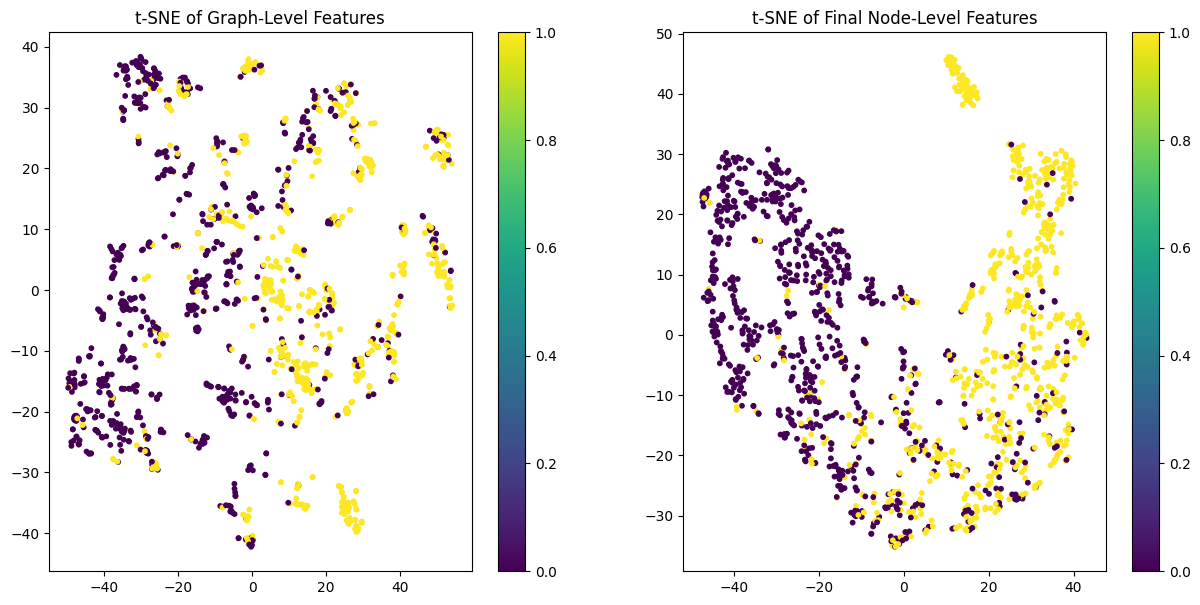

In [88]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

def plot_tsne_subplots(graph_features, node_features, labels, title_graph, title_node):
    tsne = TSNE(n_components=2)

    # Apply t-SNE to graph-level features
    graph_tsne = tsne.fit_transform(graph_features)

    # Apply t-SNE to final central node features
    node_tsne = tsne.fit_transform(node_features)

    # Create subplots
    fig, axes = plt.subplots(1, 2, figsize=(15, 7))

    # Plot t-SNE for graph-level features
    scatter_graph = axes[0].scatter(graph_tsne[:, 0], graph_tsne[:, 1], c=labels, cmap='viridis', s=10)
    axes[0].set_title(title_graph)
    plt.colorbar(scatter_graph, ax=axes[0])

    # Plot t-SNE for final node-level features
    scatter_node = axes[1].scatter(node_tsne[:, 0], node_tsne[:, 1], c=labels, cmap='viridis', s=10)
    axes[1].set_title(title_node)
    plt.colorbar(scatter_node, ax=axes[1])

    plt.show()

# Call the function to visualize both t-SNE plots
plot_tsne_subplots(all_graph_outs.numpy(), all_final_x.numpy(), all_labels.numpy(),
                   title_graph="t-SNE of Graph-Level Features",
                   title_node="t-SNE of Final Node-Level Features")
